### Iteration - 5 (QuantileTransformer)
##### First outliers treatment method

In [0]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import QuantileTransformer
from sklearn.metrics import silhouette_score, silhouette_samples


df_user_behavior = spark.table('workspace.spotify.spotify_user_behavior').toPandas()

CLUSTER_FEATURES_V5 = [
    'daily_listening_minutes',  # usage intensity
    'sessions_per_day',         # frequency
    'days_active_last_30',      # consistency
    'avg_session_minutes',      # depth
    'skip_rate',                # content friction
    'liked_songs_pct',          # positive engagement
    'ads_skipped_pct'           # monetization friction
]

In [0]:
base = df_user_behavior[['user_id'] + CLUSTER_FEATURES_V5].copy()
before_rows = len(base)
base = base.dropna(subset = CLUSTER_FEATURES_V5)
after_rows = len(base)

if before_rows != after_rows:
    print(f' Dropped {before_rows - after_rows} rows due to nulls')

In [0]:
k =4 # 3-4 clusters are consider for business personas

In [0]:
X5 = base[CLUSTER_FEATURES_V5].copy()

qt = QuantileTransformer(
    n_quantiles = 5,
    output_distribution = 'uniform',
    random_state = 42
)




X5_scaled = qt.fit_transform(X5)
X5 = pd.DataFrame(
    X5_scaled,
    columns = CLUSTER_FEATURES_V5,
    index = base.index
)

km5= KMeans(
    n_clusters = k,
    random_state = 42,
    n_init = 20,   # more stable than sklearn default (often 10)
    max_iter = 300
)

In [0]:
labels5 = km5.fit_predict(X5)
inertia5 = km5.inertia_

sil_avg_5= silhouette_score(X5, labels5)
base_iter5 = base.copy()
base_iter5['cluster']= labels5
print(f'Inertia: {round(inertia5,2)}')
print(f' Silhoutte: {round(sil_avg_5,2)}')
sizes5 = base_iter5['cluster'].value_counts().sort_index()
sizes5

Inertia: 29908.17
 Silhoutte: 0.19


cluster
0    37952
1    23557
2    26125
3    20366
Name: count, dtype: int64

In [0]:
means5= (
    base_iter5.groupby('cluster')[CLUSTER_FEATURES_V5].mean().round(3))

In [0]:
profile5 = means5.copy()
profile5.insert(0, 'cluster_size', sizes5)
display(profile5)

cluster_size,daily_listening_minutes,sessions_per_day,days_active_last_30,avg_session_minutes,skip_rate,liked_songs_pct,ads_skipped_pct
37952,15.25258247319774,1.001,20.380984381732098,15.249199238313851,0.392,0.2570803123840002,0.494202271235749
23557,48.0671329467355,1.0,26.112865381865653,48.0671329467355,0.292,0.35686963291326335,0.5135874212735697
26125,47.74068264585023,1.0,17.434038658453225,47.74068264585023,0.277,0.25518540482733043,0.6244199608688712
20366,77.81335077434863,2.631,21.72464519580021,29.24989245560967,0.304,0.2984846487984179,0.5677823410382016


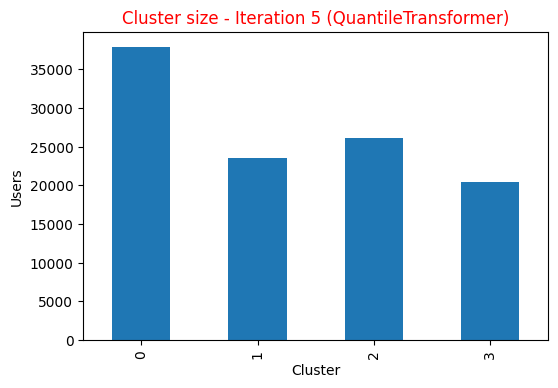

In [0]:
import matplotlib.pyplot as plt
plt.figure(figsize = (6,4))

base_iter5['cluster'].value_counts().sort_index().plot(kind= 'bar')
plt.title('Cluster size - Iteration 5 (QuantileTransformer)', color = 'red')
plt.xlabel('Cluster')
plt.ylabel('Users')
plt.show()

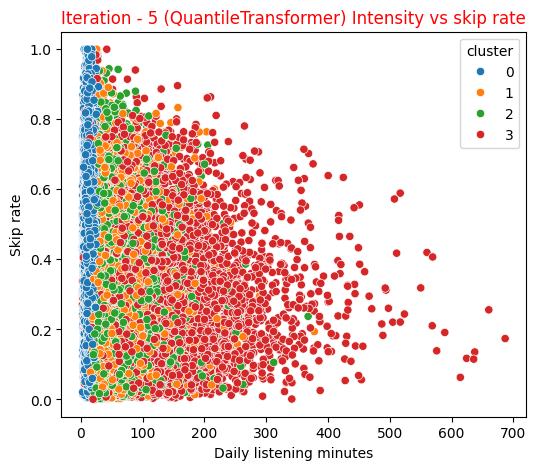

In [0]:
# scatter plot (No PCA)

# intensity vs skip
import seaborn as sns

plt.figure(figsize= (6,5))
sns.scatterplot(
    data = base_iter5,
    x = 'daily_listening_minutes',
    y = 'skip_rate',
    hue = 'cluster',
    palette = 'tab10'
)

plt.title('Iteration - 5 (QuantileTransformer) Intensity vs skip rate', color = 'red')
plt.xlabel('Daily listening minutes')
plt.ylabel('Skip rate')
plt.show()

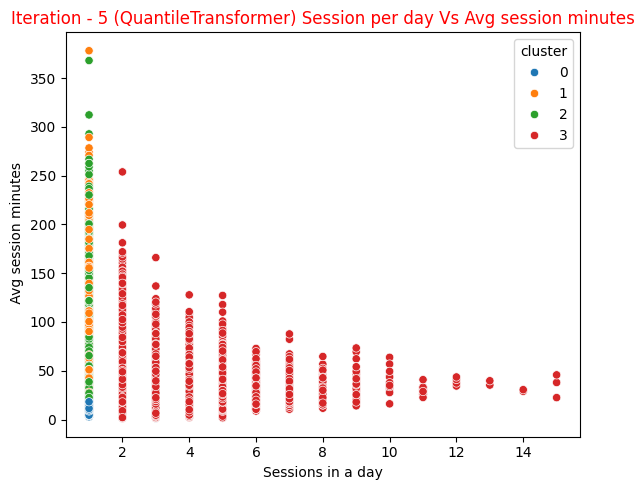

In [0]:
# frequency vs Session depth

plt.figure(figsize= (6,5))

sns.scatterplot(
    data = base_iter5,
    x = 'sessions_per_day',
    y= 'avg_session_minutes',
    hue = 'cluster',
    palette = 'tab10'
)

plt.title('Iteration - 5 (QuantileTransformer) Session per day Vs Avg session minutes', color = 'red')
plt.xlabel('Sessions in a day')
plt.ylabel(' Avg session minutes')
plt.tight_layout()
plt.show()

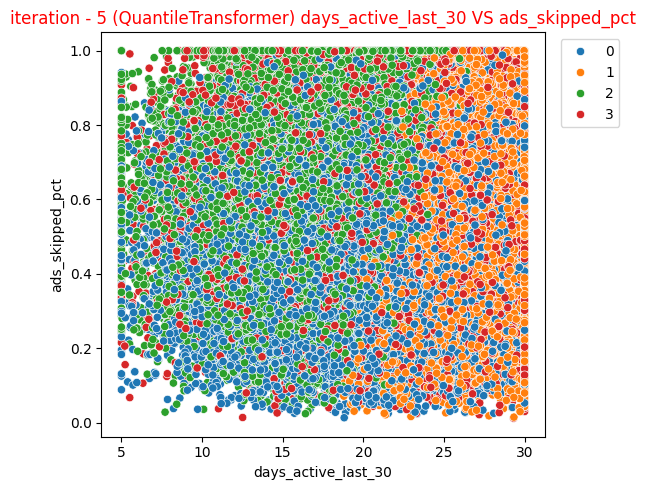

In [0]:
# consistance vs Ad friction

plt.figure(figsize= (6,5))

sns.scatterplot(
    data = base_iter5,
    x = 'days_active_last_30',
    y= 'ads_skipped_pct',
    hue = 'cluster',
    palette = 'tab10'
)

plt.title('iteration - 5 (QuantileTransformer) days_active_last_30 VS ads_skipped_pct', color = 'red')
plt.legend(bbox_to_anchor = (1.02, 1))
plt.tight_layout()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

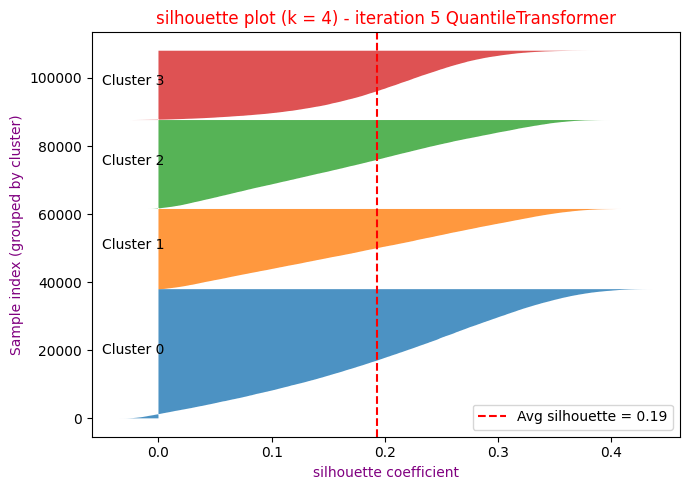

In [0]:
# silhouette Plot

sil_values_5 = silhouette_samples(X5, labels5)
sil_avg_5 = silhouette_score(X5, labels5)
plt.figure(figsize= (7,5))

y_lower = 0

vals0 = sil_values_5[labels5 == 0]
vals0.sort()
size0 = vals0.shape[0]

y_upper = y_lower + size0

plt.fill_betweenx(
    np.arange(y_lower, y_upper),    # vertical span
    0,                              # left boundary (silhoutte = 0)
    vals0,                          # right boundary (actual silhoutte values)
    alpha = 0.8
)
plt.text(
    -0.05,
    y_lower + 0.5 * size0,  # slightly left of zero
    'Cluster 0'             # vertically centered
)

y_lower = y_upper

# Cluster 1
vals1 = sil_values_5[labels5==1]
vals1.sort()
size1 = vals1.shape[0]

y_upper = y_lower + size1

plt.fill_betweenx(
    np.arange(y_lower, y_upper),
    0,
    vals1,
    alpha = 0.8
    )
plt.text(-0.05,
         y_lower + 0.5 * size1, 'Cluster 1')

y_lower = y_upper

# cluster 2
vals2 = sil_values_5[labels5 == 2]
vals2.sort()

size2 = vals2.shape[0]
y_upper = y_lower + size2
plt.fill_betweenx(np.arange(y_lower, y_upper), 0, vals2, alpha = 0.8)
plt.text(-0.05, y_lower + 0.5 * size2, 'Cluster 2')

y_lower = y_upper

# cluster 3
vals3 = sil_values_5[labels5 == 3]
vals3.sort()
size3 = vals3.shape[0]
y_upper = y_lower + size3
plt.fill_betweenx(np.arange(y_lower, y_upper), 0, vals3, alpha = 0.8)
plt.text(-0.05, y_lower + 0.5 * size3, 'Cluster 3')

y_lower = y_upper

plt.axvline(
    x= sil_avg_5,
    color = 'red',
    linestyle = '--',
    label =f"Avg silhouette = {sil_avg_5:.2f}"
)

plt.title('silhouette plot (k = 4) - iteration 5 QuantileTransformer', color = 'red')
plt.xlabel('silhouette coefficient', color = 'purple')
plt.ylabel('Sample index (grouped by cluster)', color = 'purple')
plt.legend()
plt.tight_layout()
plt.show